# Dataset 3 – Rice Grains
**Implementation:** Akshit (algorithms/akshit/)  
**Algorithms:** TBD  
**Evaluation:** Stratified 10-fold CV · Accuracy · Macro F1

In [1]:
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run(['git', 'clone', f'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

if '.' not in sys.path:
    sys.path.insert(0, '.')


In [3]:
print(f"Columns: {list(df.columns)}")

Columns: ['attr1_num', 'attr2_num', 'attr3_num', 'attr4_num', 'attr5_num', 'attr6_num', 'attr7_num', 'label']


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import from your GitHub directories
from algorithms.akshit.hw_1 import knn_predict, normalize
from algorithms.akshit.hw_3 import RandomForest, evaluate_metrics, stratified_kfold, DecisionTree
from algorithms.vishal import utils

# --- Data Loading ---
df = pd.read_csv('data/rice.csv')

# UPDATED: Using 'label' instead of 'Class'
target_col = 'label'

X_raw = df.drop(columns=[target_col]).values.astype(float)
y = df[target_col].values.astype(str)

print(f"Instances: {len(y)}, Features: {X_raw.shape[1]}")
print(f"Classes: {dict(zip(*np.unique(y, return_counts=True)))}")


Instances: 3810, Features: 7
Classes: {np.str_('Cammeo'): np.int64(1630), np.str_('Osmancik'): np.int64(2180)}


## TODO: Algorithm 1 – Hyperparameter Sweep

In [5]:
# --- Algorithm 1 Sweep: k-NN ---
k_values = [1, 3, 5, 7, 9, 11]
knn_results = {'k': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for k-NN...")
folds = stratified_kfold(X_raw, y, k=10)

for k in k_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds:
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Normalize strictly within the fold
        X_tr_n, X_te_n = normalize(X_tr, X_te)

        # Predict
        y_pred = knn_predict(X_tr_n, list(y_tr), X_te_n, k)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    knn_results['k'].append(k)
    knn_results['accuracy'].append(np.mean(acc_list))
    knn_results['f1'].append(np.mean(f1_list))
    print(f"k={k:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")

Running 10-Fold CV for k-NN...
k=1  | Acc: 0.8853 | F1: 0.8994
k=3  | Acc: 0.9118 | F1: 0.9229
k=5  | Acc: 0.9215 | F1: 0.9315
k=7  | Acc: 0.9236 | F1: 0.9333
k=9  | Acc: 0.9239 | F1: 0.9336
k=11 | Acc: 0.9249 | F1: 0.9345


## TODO: Algorithm 2 – Hyperparameter Sweep

In [11]:
# --- Algorithm 2 Sweep: Decision Tree ---------
depth_values = [2, 4, 6, 8, 10]
dt_results = {'max_depth': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for Decision Tree...")
folds = stratified_kfold(X_raw, y, k=10)

for depth in depth_values:
    acc_list, f1_list = [], []
    fold_num = 1

    for train_idx, test_idx in folds:
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # 2. Increased min_size_for_split from 2 to 10
        # This stops the tree from doing complex math for nodes with only a few samples
        dt = DecisionTree(max_depth=depth, min_size_for_split=10)
        dt.fit(X_tr, y_tr)

        # Predict
        y_pred = dt.predict(X_te)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

        # 3. Keep the progress tracker!
        print(f"  [Progress] max_depth={depth:<2} | Fold {fold_num}/10 complete")
        fold_num += 1

    dt_results['max_depth'].append(depth)
    dt_results['accuracy'].append(np.mean(acc_list))
    dt_results['f1'].append(np.mean(f1_list))
    print(f"*** RESULT: max_depth={depth:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f} ***\n")

Running 10-Fold CV for Decision Tree...
  [Progress] max_depth=2  | Fold 1/10 complete
  [Progress] max_depth=2  | Fold 2/10 complete
  [Progress] max_depth=2  | Fold 3/10 complete
  [Progress] max_depth=2  | Fold 4/10 complete
  [Progress] max_depth=2  | Fold 5/10 complete
  [Progress] max_depth=2  | Fold 6/10 complete
  [Progress] max_depth=2  | Fold 7/10 complete
  [Progress] max_depth=2  | Fold 8/10 complete
  [Progress] max_depth=2  | Fold 9/10 complete
  [Progress] max_depth=2  | Fold 10/10 complete
*** RESULT: max_depth=2  | Acc: 0.9247 | F1: 0.9337 ***

  [Progress] max_depth=4  | Fold 1/10 complete
  [Progress] max_depth=4  | Fold 2/10 complete
  [Progress] max_depth=4  | Fold 3/10 complete
  [Progress] max_depth=4  | Fold 4/10 complete
  [Progress] max_depth=4  | Fold 5/10 complete
  [Progress] max_depth=4  | Fold 6/10 complete
  [Progress] max_depth=4  | Fold 7/10 complete
  [Progress] max_depth=4  | Fold 8/10 complete
  [Progress] max_depth=4  | Fold 9/10 complete
  [Progre

## TODO: Plots & Summary Table

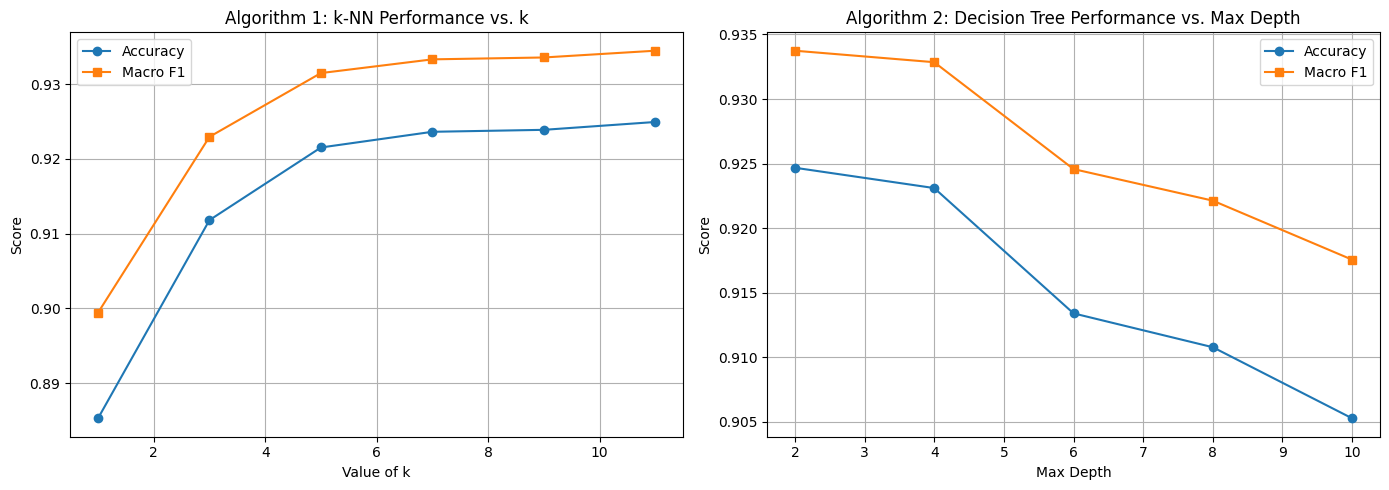


=== SUMMARY TABLE ===
k-NN Results:
 k  accuracy       f1
 1  0.885302 0.899428
 3  0.911811 0.922949
 5  0.921522 0.931475
 7  0.923622 0.933310
 9  0.923885 0.933561
11  0.924934 0.934465

Decision Tree Results:
 max_depth  accuracy       f1
         2  0.924672 0.933743
         4  0.923097 0.932853
         6  0.913386 0.924569
         8  0.910761 0.922121
        10  0.905249 0.917546


In [13]:
# --- Plotting Learning Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k-NN Plot
axes[0].plot(knn_results['k'], knn_results['accuracy'], marker='o', label='Accuracy')
axes[0].plot(knn_results['k'], knn_results['f1'], marker='s', label='Macro F1')
axes[0].set_title('Algorithm 1: k-NN Performance vs. k')
axes[0].set_xlabel('Value of k')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True)

# Decision Tree Plot
axes[1].plot(dt_results['max_depth'], dt_results['accuracy'], marker='o', label='Accuracy')
axes[1].plot(dt_results['max_depth'], dt_results['f1'], marker='s', label='Macro F1')
axes[1].set_title('Algorithm 2: Decision Tree Performance vs. Max Depth')
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n=== SUMMARY TABLE ===")
print("k-NN Results:")
df_knn = pd.DataFrame(knn_results)
print(df_knn.to_string(index=False))

print("\nDecision Tree Results:")
df_dt = pd.DataFrame(dt_results)
print(df_dt.to_string(index=False))